In [1]:
import pandas as pd
import os
from nltk.tokenize import word_tokenize
import numpy as np
import csv
import matplotlib.pyplot as plt
import re

In [2]:
OUTPUT_DIR = './processedData/'

In [3]:
prompt_df = pd.read_csv('../promptDataPreparation/promptDataPreparation.csv')

In [4]:
sentence_lengths = {}
count_checker = {'LDA': {'met': 0, 'unmet': 0}, 'MATAVE': {'met': 0, 'unmet': 0}}
for topic_model in os.listdir(f'./data'):
    if os.path.isdir(f'./data/{topic_model}'):
        sentence_lengths[topic_model] = {}
        for file in os.listdir(f'./data/{topic_model}'):
            if file.endswith('.csv'):
                temp_file_name = file.split('_')[1].replace('.csv', '')
                if temp_file_name not in sentence_lengths[topic_model]:
                    sentence_lengths[topic_model][temp_file_name] = []
                temp_df = pd.read_csv(f'./data/{topic_model}/{file}')['report'].to_list()
                count_checker[topic_model][temp_file_name] += len(temp_df)
                for note in temp_df:
                    sentence_lengths[topic_model][temp_file_name].append(len(word_tokenize(note)))

In [5]:
count_checker

{'LDA': {'met': 1091, 'unmet': 1420}, 'MATAVE': {'met': 1122, 'unmet': 1341}}

In [6]:
for topic_model in ['LDA', 'MATAVE']:
    for need in ['met', 'unmet']:
        print(len(sentence_lengths[topic_model][need]), count_checker[topic_model][need])

1091 1091
1420 1420
1122 1122
1341 1341


MATAVE met


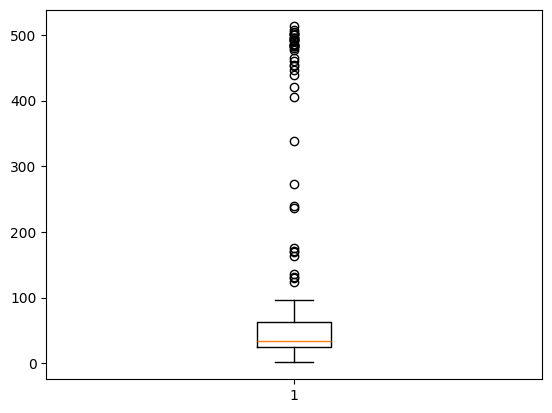

MATAVE unmet


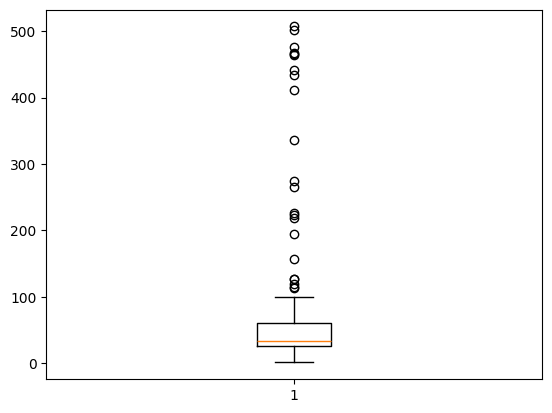

LDA met


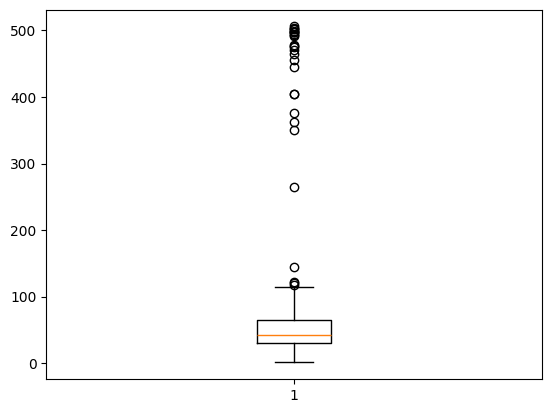

LDA unmet


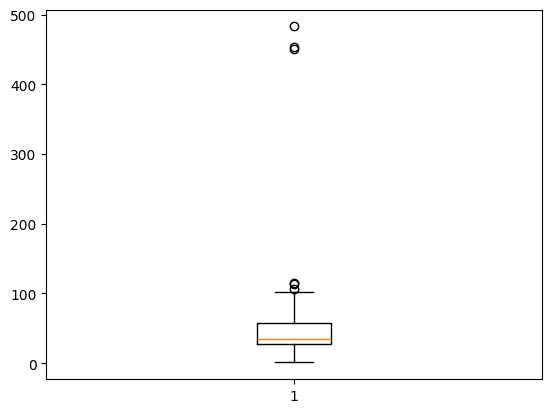

In [7]:
for dataset, values in sentence_lengths.items():
    for model_name, model_values in values.items():
        print(dataset, model_name)
        plt.boxplot(model_values);
        plt.show()

In [8]:
upper_and_lower_bounds = {}

for topic_model, values in sentence_lengths.items():
    upper_and_lower_bounds[topic_model] = {}
    
    for needs, lengths in values.items():
        l = np.array(lengths)
        
        q1 = np.quantile(l, 0.25)
        q3 = np.quantile(l, 0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        # store bounds
        upper_and_lower_bounds[topic_model][needs] = {
            'lower': lower,
            'upper': upper
        }

In [9]:
upper_and_lower_bounds

{'MATAVE': {'met': {'lower': np.float64(-30.5), 'upper': np.float64(117.5)},
  'unmet': {'lower': np.float64(-25.0), 'upper': np.float64(111.0)}},
 'LDA': {'met': {'lower': np.float64(-22.5), 'upper': np.float64(117.5)},
  'unmet': {'lower': np.float64(-19.5), 'upper': np.float64(104.5)}}}

In [10]:
def clean_note(text):
    text = re.sub(r'^[\s"]+|[\s"]+$', '', text)   # strip edge quotes/spaces
    text = re.sub(r'\*', '', text)                 # remove asterisks
    text = re.sub(r'\s+', ' ', text)              # normalize whitespace
    return text.strip()

In [11]:
fake_notes = pd.read_excel('./fake_notes.xlsx')

In [12]:
fake_notes

,Note,Needs
0,John was assisted with a shower this morning. ...,met
1,Sarah had a GP appointment this morning and th...,met
2,Michael showered independently this morning. I...,met
3,"Rachel was assisted with a wash this morning, ...",met
4,Darragh has been started on an End of Life car...,met
5,Billy’s sister has expressed her concern that ...,unmet
6,Stephen complained of pain 8/10 in his right h...,unmet
7,Andrea experienced nausea during lunch today. ...,unmet
8,Louise was assisted with a wash this morning. ...,unmet
9,Michelle was assisted with her breakfast this ...,unmet


In [13]:
# Keep texts that fall within the Tukey fences in the list.
for temp_topic_model in os.listdir(f'./data'):
    if os.path.isdir(f'./data/{temp_topic_model}'):
        notes_for_outputs = []
        relevant_prompts = []
        needs = []
        topic_models = []
        prompt_ids = []
        raw_notes = []
        for file in os.listdir(f'./data/{temp_topic_model}'):
            if file.endswith('.csv'):
                fake_note_id = file.replace('.csv', '').split('_')
                prompt = fake_notes[fake_notes['Needs'] == fake_note_id[1]]['Note'].tolist()[int(fake_note_id[0])]
                notes = pd.read_csv(f'./data/{temp_topic_model}/{file}')['report'].to_list()
                raw_notes.extend(notes)
                for note in notes:
                    # raw_segments = re.split(r'\s*"+(?:\s*"+)+\s*', note)
                    raw_segments = re.split(r'\s*(?:"{2,}\s*){1,}"+\s*', note)
                    for segment in raw_segments:
                        segment = clean_note(segment)

                        if not segment:
                            continue

                        temp_length = len(word_tokenize(segment))
                        # Filter based on lower bound vs 6 words max and upper bound. 
                        if max(upper_and_lower_bounds[temp_topic_model][fake_note_id[1]]['lower'], 5) <= temp_length <= upper_and_lower_bounds[temp_topic_model][fake_note_id[1]]['upper']:
                            # remove any note with accidental reference to the topic model keywords
                            if 'other topic keywords:' not in segment.lower():
                                # Remove accidental reference to the input prompt.
                                if prompt.lower() not in segment.lower():
                                    needs.append(fake_note_id[1])
                                    relevant_prompts.append(prompt)
                                    
                                    notes_for_outputs.append(segment)
                                    prompt_ids.append(file.replace('.csv', ''))
                                    topic_models.append(temp_topic_model)
                                else:
                                    # print(f'{dataset} DIRECT PROMPT REFERENCE {prompt} - {note}')
                                    pass
                            else:
                                # print(f'{dataset} DIRECT KEYWORDS REFERENCE {prompt} - {note}')
                                pass
                        else:
                            # print(f"{dataset} TOO LONG {note} is {temp_length} tokens long, which falls outside the range of {upper_and_lower_bounds[dataset][temp_topic_model]['lower']} - {upper_and_lower_bounds[dataset][temp_topic_model]['upper']}")
                            pass
        os.makedirs(f'./{OUTPUT_DIR}/', exist_ok=True)
        output_df = pd.DataFrame({
            'needs' : needs,
            'topic_model' : topic_models,
            'prompt_id' : prompt_ids,
            'example_text_in_prompt' : relevant_prompts,
            'report' : notes_for_outputs,
        })
        output_df = output_df[output_df['report'].notna() & (output_df['report'] != "")]
        output_df = output_df.drop_duplicates(subset=['report'])
        output_df.to_csv(f'./{OUTPUT_DIR}/{temp_topic_model}.csv', index=False, quoting=csv.QUOTE_ALL, encoding='utf-8', lineterminator='\n')
        print(f"{temp_topic_model}: {len(raw_notes)} vs {len(output_df)}")

MATAVE: 2463 vs 2313
LDA: 2511 vs 2396
